In [1]:
import dxpy
import pandas as pd
import numpy as np

# Splitting Data
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt

# Read File

In [2]:
# Download the file
dxpy.download_dxfile('file-GpXGP18JjKX5JQvYy14J12Fx', 'file.csv')

In [3]:
# Read file into the pandas Data Frame
df = pd.read_csv('file.csv', sep='\t')

In [ ]:
# First five rows
df.head()

In [5]:
# Shape of the dataframe
df.shape

(17684, 2923)

In [6]:
# Number of cases and controls
df.value_counts('status')

status
0    16331
1     1353
dtype: int64

In [7]:
# Check missing values
df.isna().sum()

alcam       0
lilrb5      0
lilrb1      0
ccl15       0
ccl16       0
           ..
ctss        0
cst1        0
UKBB_GRS    0
grs         0
status      0
Length: 2923, dtype: int64

In [8]:
# Split data to input and output
X = df.drop(columns=['status'])
y = df['status']

# Analysis

## Data splitting

In [9]:
# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# Define stratified k fold cross validation with 5 folds
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Class Weight

In [11]:
# Calculate class weights
class_weights = {0: 1, 1: len(y_train[y_train==0]) / len(y_train[y_train==1])}

In [12]:
class_weights

{0: 1, 1: 12.074861367837338}

## Feature Selection

In [ ]:
'''# Define parameters for random forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}'''

In [ ]:
'''%%time
# Define Random Forest classifier
rf_clf = RandomForestClassifier(random_state=42, class_weight=class_weights)
# Define Gridsearchcv model
rf_grid_search = GridSearchCV(rf_clf, rf_param_grid, cv=kfold, n_jobs=-1,
                              scoring='recall')
# Fit model
rf_grid_search.fit(X_train, y_train)'''

In [ ]:
'''# best params
rf_grid_search.best_params_'''

In [ ]:
'''# Get the best estimator from the grid search
importances = rf_grid_search.best_estimator_.feature_importances_

# Create a DataFrame of feature importances
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Save to csv file
feature_importance_df.to_csv('features.csv', sep='\t', index=False)'''

In [13]:
# Download important features file
dxpy.download_dxfile('file-GpY7gBQJjKX0KX3k20Y6FpXq', 'features.csv')

In [14]:
# Save file in pandas dataframe
features_df = pd.read_csv('features.csv', sep='\t')

In [15]:
features_df.head()

,feature,importance
0,grs,0.024352
1,UKBB_GRS,0.015627
2,paep,0.010124
3,fshb,0.007456
4,cga,0.006966


In [16]:
features_df = features_df.drop(features_df.index[1])

In [17]:
# Select first 50 most important features to train the model
top_features = features_df['feature'].head(50)

In [18]:
# Filter train and test input dataframes with selected features
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

## Model

In [19]:
# Define parameters for DT
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [20]:
# Define DT classifier
dt = DecisionTreeClassifier(random_state=42, class_weight=class_weights)

In [21]:
# Set up GridSearchCV with K-Fold Cross-Validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=kfold,
                           scoring='recall')

In [22]:
%%time
# Fit the model
grid_search.fit(X_train_selected, y_train)

CPU times: user 6min 55s, sys: 23.1 ms, total: 6min 55s
Wall time: 6min 55s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(class_weight={0: 1,
                                                            1: 12.074861367837338},
                                              random_state=42),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='recall')

In [23]:
# Get the best parameters and recall
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score(recall): {grid_search.best_score_}')

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best score(recall): 0.5258960573476703


In [24]:
# Get the predicted probabilities
y_proba = grid_search.best_estimator_.predict_proba(X_test_selected)[:, 1]

## Metrics

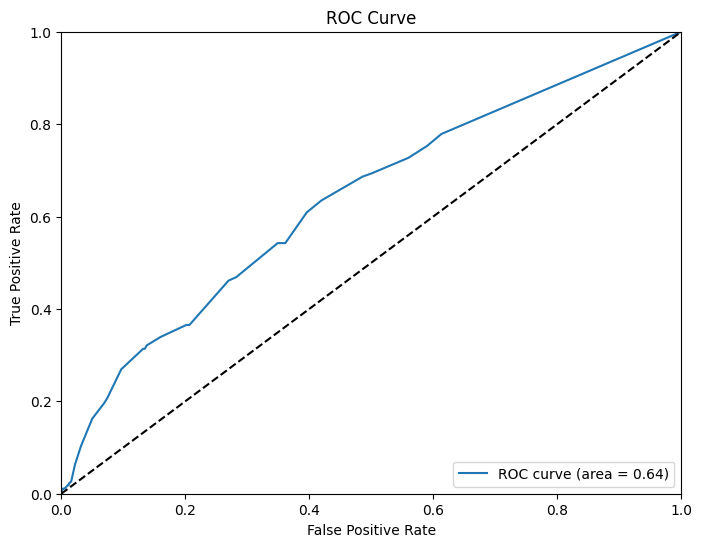

In [25]:
# ROC Curve

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_proba)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Apply different thresholds

In [26]:
# Thresholds to consider
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

In [27]:
# Initialize lists to store metrics
precisions = []
recalls = []
f1_scores = []
specificities = []
g_means = []

In [28]:
# Loop over thresholds
for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary'
    )
    specificity = tn / (tn + fp)
    g_mean = np.sqrt(recall * specificity)
    
    # Append metrics to lists
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    specificities.append(specificity)
    g_means.append(g_mean)

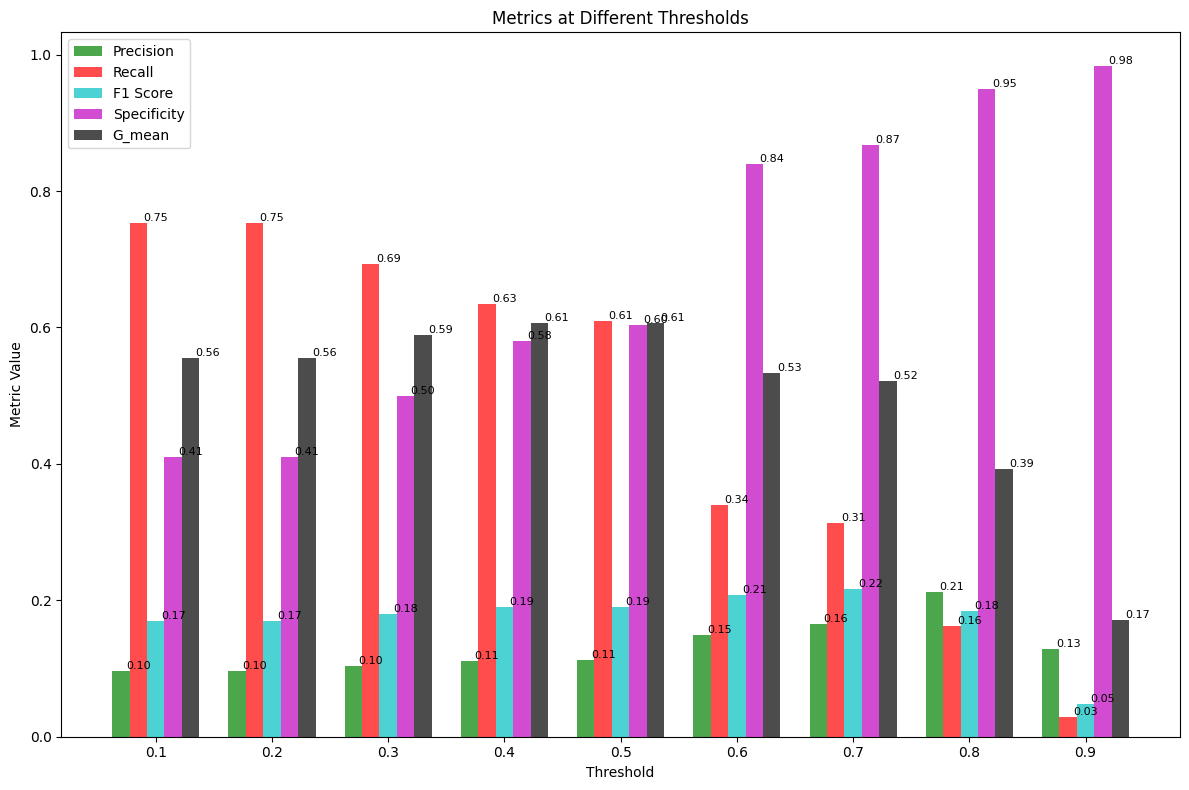

In [29]:
# Plot metrics as a grouped bar plot
bar_width = 0.15
index = np.arange(len(thresholds))

plt.figure(figsize=(12, 8))

def add_value_labels(data, offset):
    for i, v in enumerate(data):
        plt.text(i + offset, v, f'{v:.2f}', ha='center', va='bottom',
                 fontsize=8)

plt.bar(index, precisions, bar_width, label='Precision', color='g',
        alpha=0.7)
plt.bar(index + bar_width, recalls, bar_width, label='Recall', color='r',
        alpha=0.7)
plt.bar(index + 2 * bar_width, f1_scores, bar_width, label='F1 Score',
        color='c', alpha=0.7)
plt.bar(index + 3 * bar_width, specificities, bar_width, label='Specificity',
        color='m', alpha=0.7)
plt.bar(index + 4 * bar_width, g_means, bar_width, label='G_mean',
        color='black', alpha=0.7)

# Add labels
add_value_labels(precisions, bar_width)
add_value_labels(recalls, 2 * bar_width)
add_value_labels(f1_scores, 3 * bar_width)
add_value_labels(specificities, 4 * bar_width)
add_value_labels(g_means, 5 * bar_width)

plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Metrics at Different Thresholds')
plt.xticks(index + 2 * bar_width, thresholds)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

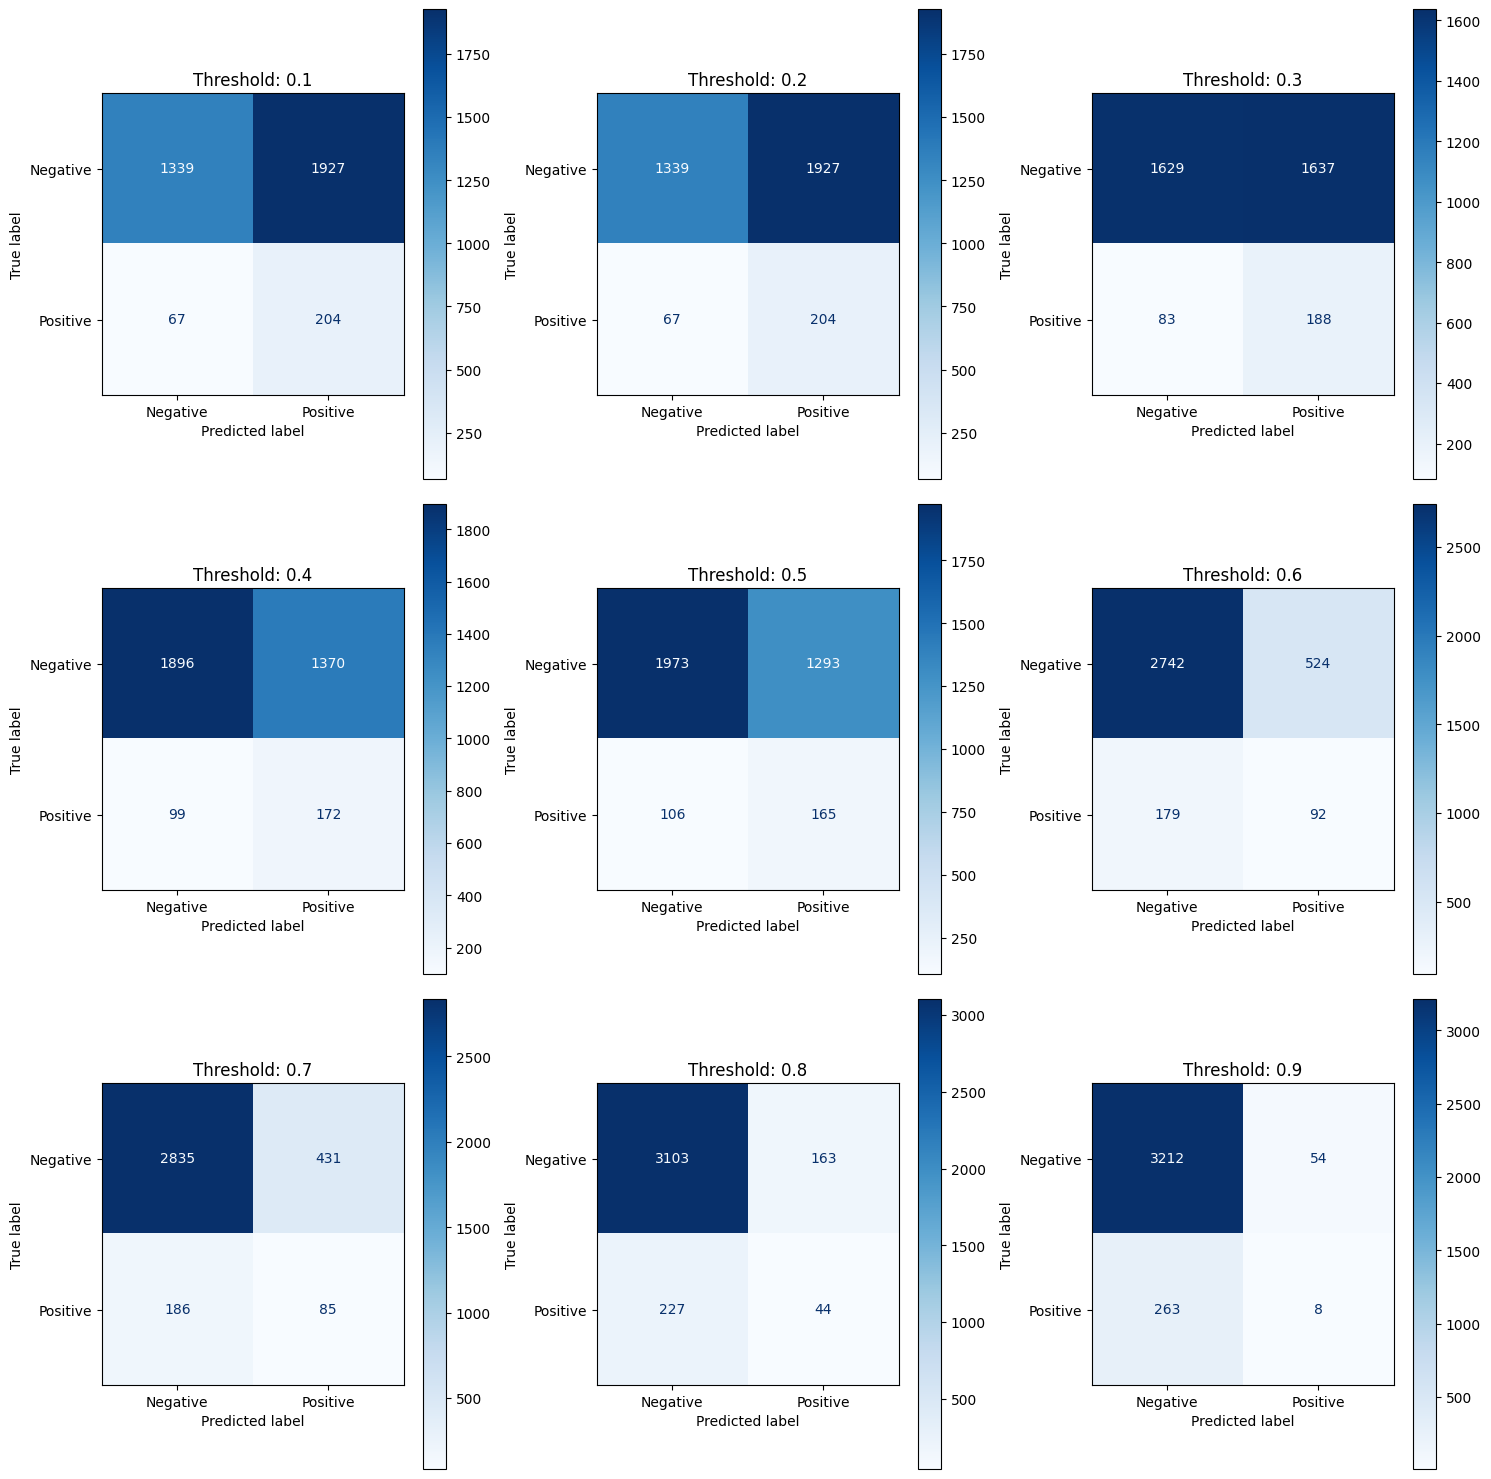

In [30]:
# Create subplots for confusion matrices
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()  # Flatten the axes array

for i, threshold in enumerate(thresholds):
    y_pred = (y_proba >= threshold).astype(int)
    
    # Plot the confusion matrix using sklearn
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], display_labels=['Negative', 'Positive'],
        cmap='Blues'
    )
    axes[i].set_title(f'Threshold: {thresholds[i]}')

# Adjust layout
plt.tight_layout()
plt.show()